# Bài tập về nhà - Buổi 2 Xác suất thống kê cho AI

## Tải thư viện & Chuẩn bị dữ liệu 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
print("Thư viện đã được cài đặt.")

Thư viện đã được cài đặt.


In [4]:
df = sns.load_dataset("iris") 
print(df.head()) 
print(df.shape)
print(df.dtypes)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


## Phần 1 - Thống kế mô tả & đặc trưng

### 1.1 Đọc dữ liệu - 5 dòng đầu, shape và dtypes

In [5]:
display(df.head())

print(f'\nSố dòng: {df.shape[0]}, Số cột: {df.shape[1]}')
print(f'\nKiểu dữ liệu từng cột:\n{df.dtypes}')
print(f'\nGiá trị null:\n{df.isnull().sum()}')

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Số dòng: 150, Số cột: 5

Kiểu dữ liệu từng cột:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Giá trị null:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


### 1.2 Thống kê mô tả từng biến số

In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

stats_dict = {}
for col in numeric_cols:
    s = df[col]
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    stats_dict[col] = {
        'mean'   : round(s.mean(), 4),
        'median' : round(s.median(), 4),
        'mode'   : round(s.mode()[0], 4),
        'var'    : round(s.var(), 4),
        'std'    : round(s.std(), 4),
        'min'    : round(s.min(), 4),
        'max'    : round(s.max(), 4),
        'Q1'     : round(Q1, 4),
        'Q3'     : round(Q3, 4),
        'IQR'    : round(Q3 - Q1, 4),
    }

stats_df = pd.DataFrame(stats_dict).T
display(stats_df)

,mean,median,mode,var,std,min,max,Q1,Q3,IQR
sepal_length,5.8433,5.80,5.0,0.6857,0.8281,4.3,7.9,5.1,6.4,1.3
sepal_width,3.0573,3.00,3.0,0.1900,0.4359,2.0,4.4,2.8,3.3,0.5
petal_length,3.7580,4.35,1.4,3.1163,1.7653,1.0,6.9,1.6,5.1,3.5
petal_width,1.1993,1.30,0.2,0.5810,0.7622,0.1,2.5,0.3,1.8,1.5


### 1.3 Thống kê theo nhóm species

In [7]:
group_mean = df.groupby('species')[numeric_cols].mean().round(3)
group_std  = df.groupby('species')[numeric_cols].std().round(3)

print('Mean theo species')
display(group_mean)
print('\nStd theo species')
display(group_std)

Mean theo species


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026



Std theo species


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,0.352,0.379,0.174,0.105
versicolor,0.516,0.314,0.470,0.198
virginica,0.636,0.322,0.552,0.275


**Nhận xét:**  
- **Virginica** có kích thước lớn nhất ở cả petal và sepal, nổi bật ở `petal_length` (mean ≈ 5.55) và `petal_width` (mean ≈ 2.03).  
- **Setosa** nhỏ hơn hẳn so với 2 loài còn lại, đặc biệt `petal_length` (mean ≈ 1.46) - khác biệt rõ ràng nhất.  
- **Versicolor** nằm ở mức trung gian so với 2 loài còn lại.  
→ Qua đó, ta thấy được rằng biến **petal_length** và **petal_width** là hai đặc trưng phân biệt nhóm mạnh nhất.

## Phần 2 - Phân phối xác suất

### 2.1 Histogram + KDE từng biến số

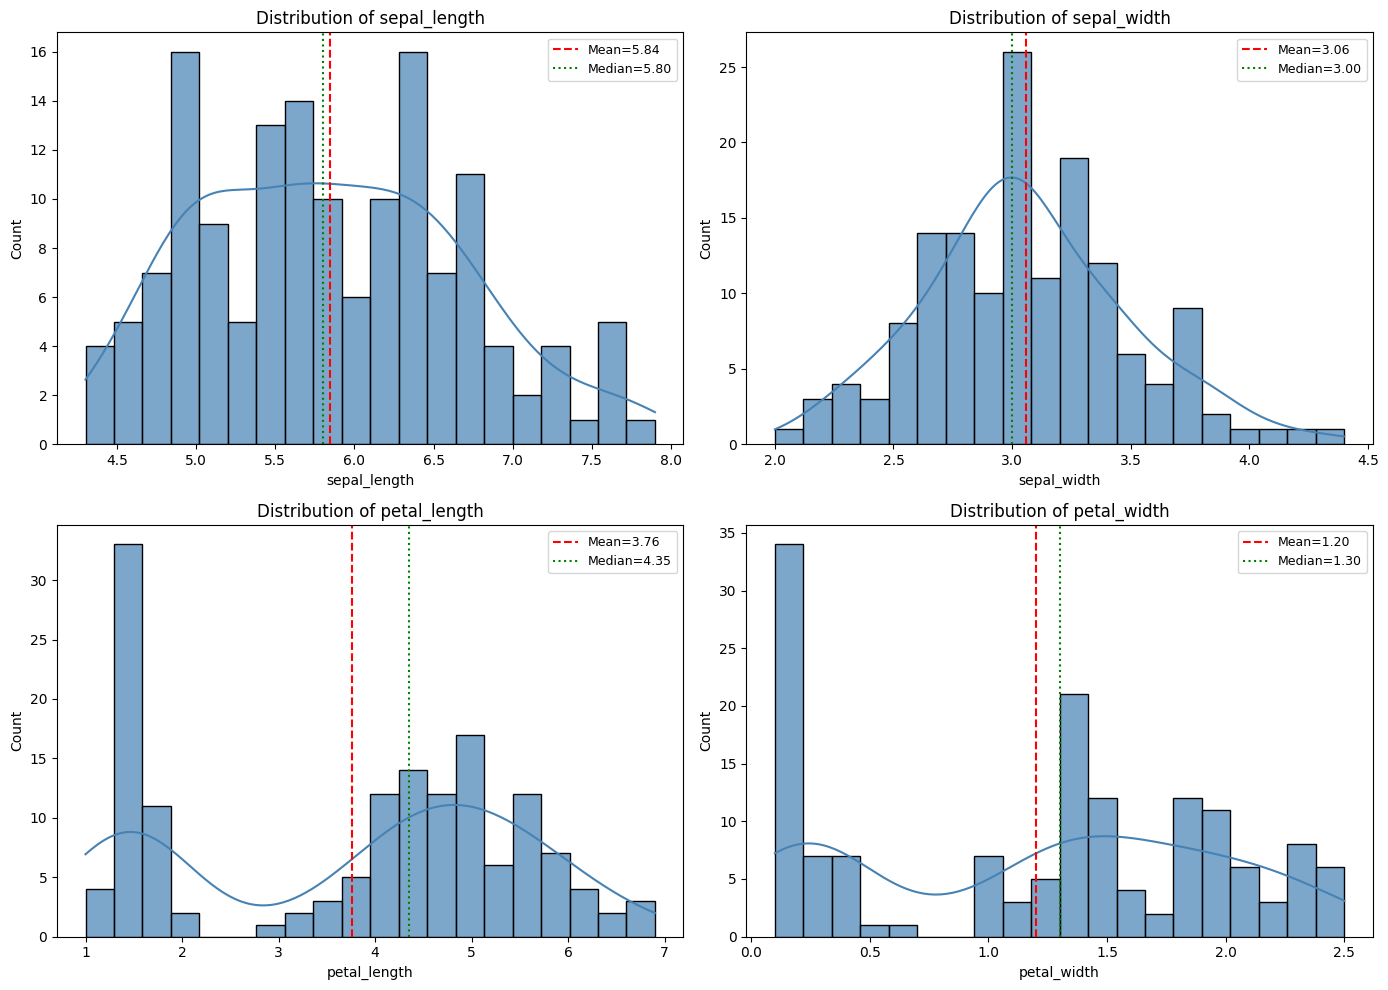

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', bins=20, alpha=0.7)
    ax.axvline(df[col].mean(),   color='red',    linestyle='--', label=f'Mean={df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='green',  linestyle=':',  label=f'Median={df[col].median():.2f}')
    ax.set_title(f'Distribution of {col}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('hist_kde.png', dpi=120, bbox_inches='tight')
plt.show()

**Nhận xét hình dạng phân phối:**  
- `sepal_length`, `sepal_width`: tương đối gần phân phối chuẩn (bell-shaped), `sepal_width` khá đối xứng.  
- `petal_length`, `petal_width`: **bimodal** (2 đỉnh rõ rệt) - phản ánh sự tách biệt giữa Setosa và hai loài còn lại.  
- `sepal_length` lệch phải nhẹ; `petal_width` lệch phải mạnh hơn.

### 2.2 Boxplot từng biến theo species

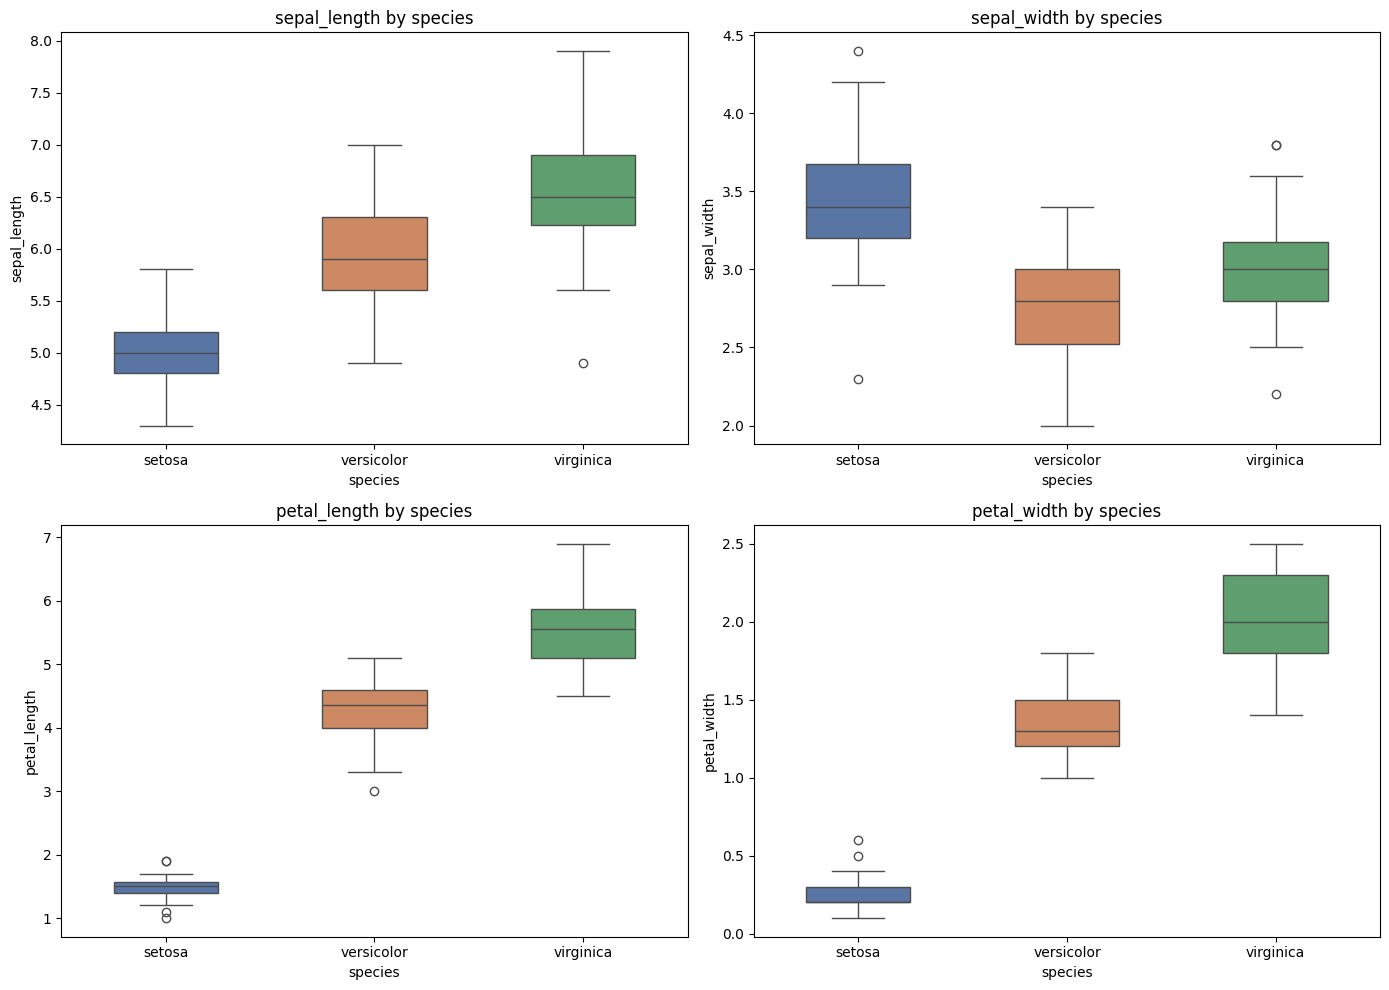

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

palette = {'setosa': '#4C72B0', 'versicolor': '#DD8452', 'virginica': '#55A868'}

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='species', y=col, hue='species', ax=axes[i],
                palette=palette, width=0.5, legend=False)
    axes[i].set_title(f'{col} by species')

plt.tight_layout()
plt.savefig('boxplot_species.png', dpi=120, bbox_inches='tight')
plt.show()

**Nhận xét:**  
- `petal_length` và `petal_width`: 3 loài tách nhau rõ ràng, IQR không chồng lấp nhiều → rất tốt cho phân loại.  
- `sepal_width`: Setosa có median cao nhất nhưng overlap nhiều giữa Versicolor và Virginica.  
- Một số outlier nhỏ xuất hiện ở `sepal_width` (Versicolor).

### 2.3 Mô phỏng Normal Distribution - so với dữ liệu thực

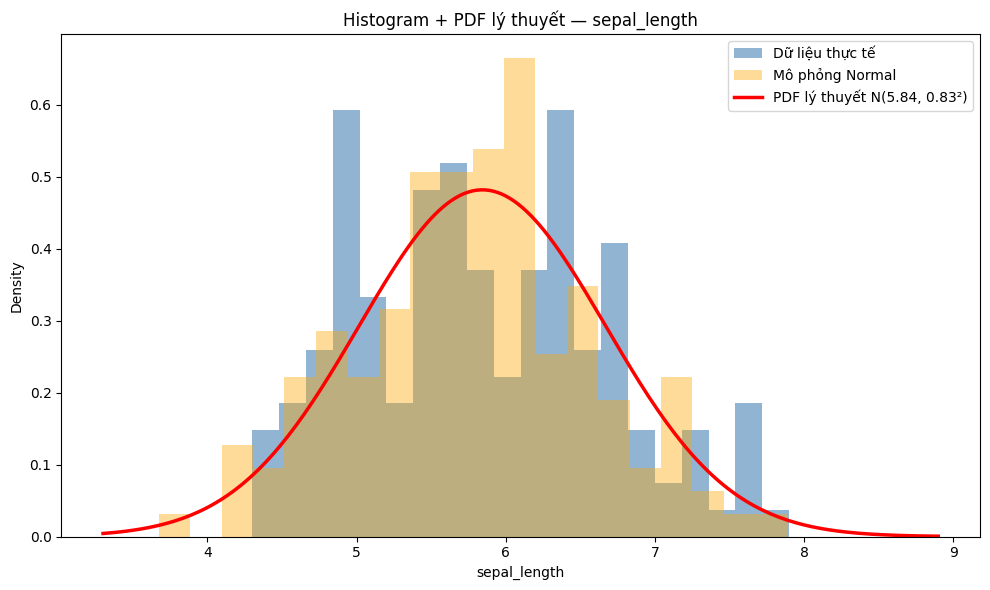

Skewness = 0.3149
→ Dữ liệu khá gần phân phối chuẩn


In [10]:
col = 'sepal_length'
mu, sigma = df[col].mean(), df[col].std()

# Sinh mẫu mô phỏng
np.random.seed(42)
simulated = np.random.normal(loc=mu, scale=sigma, size=len(df))

# Đường PDF lý thuyết
x = np.linspace(df[col].min() - 1, df[col].max() + 1, 200)
pdf_theoretical = stats.norm.pdf(x, mu, sigma)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df[col],   bins=20, density=True, alpha=0.6, color='steelblue', label='Dữ liệu thực tế')
ax.hist(simulated, bins=20, density=True, alpha=0.4, color='orange',    label='Mô phỏng Normal')
ax.plot(x, pdf_theoretical, 'r-', lw=2.5, label=f'PDF lý thuyết N({mu:.2f}, {sigma:.2f}²)')

ax.set_title(f'Histogram + PDF lý thuyết — {col}')
ax.set_xlabel(col)
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.savefig('normal_fit.png', dpi=120, bbox_inches='tight')
plt.show()

# Skewness test
skew = df[col].skew()
print(f"Skewness = {skew:.4f}")
if abs(skew) < 0.5:
    print("→ Dữ liệu khá gần phân phối chuẩn")
elif abs(skew) < 1:
    print("→ Dữ liệu hơi lệch nhưng vẫn chấp nhận được")
else:
    print("→ Dữ liệu lệch đáng kể, không giống chuẩn")

**Nhận xét mức độ khớp:**  
- `sepal_length` có hình dạng tương đối gần Normal, đường PDF lý thuyết bám khá sát histogram.  
- Tuy nhiên, do dataset gộp 3 loài, phân phối thực tế có xu hướng hơi lệch và không hoàn toàn unimodal.  
- Skewness < 0.5 → dữ liệu gần giống phân phối chuẩn, nhưng về mặt thống kê chính xác thì **không phải Normal thuần**. 

## Phần 3 - Phân tích đa biến & tương quan

### 3.1 Ma trận Covariance & Correlation

In [17]:
cov_matrix  = df[numeric_cols].cov().round(4)
corr_matrix = df[numeric_cols].corr().round(4)

print(' Ma trận Covariance ')
display(cov_matrix)
print('\n Ma trận Correlation ')
display(corr_matrix)

 Ma trận Covariance 


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.6857,-0.0424,1.2743,0.5163
sepal_width,-0.0424,0.1900,-0.3297,-0.1216
petal_length,1.2743,-0.3297,3.1163,1.2956
petal_width,0.5163,-0.1216,1.2956,0.5810



 Ma trận Correlation 


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.0000,-0.1176,0.8718,0.8179
sepal_width,-0.1176,1.0000,-0.4284,-0.3661
petal_length,0.8718,-0.4284,1.0000,0.9629
petal_width,0.8179,-0.3661,0.9629,1.0000


### 3.2 Heatmap tương quan

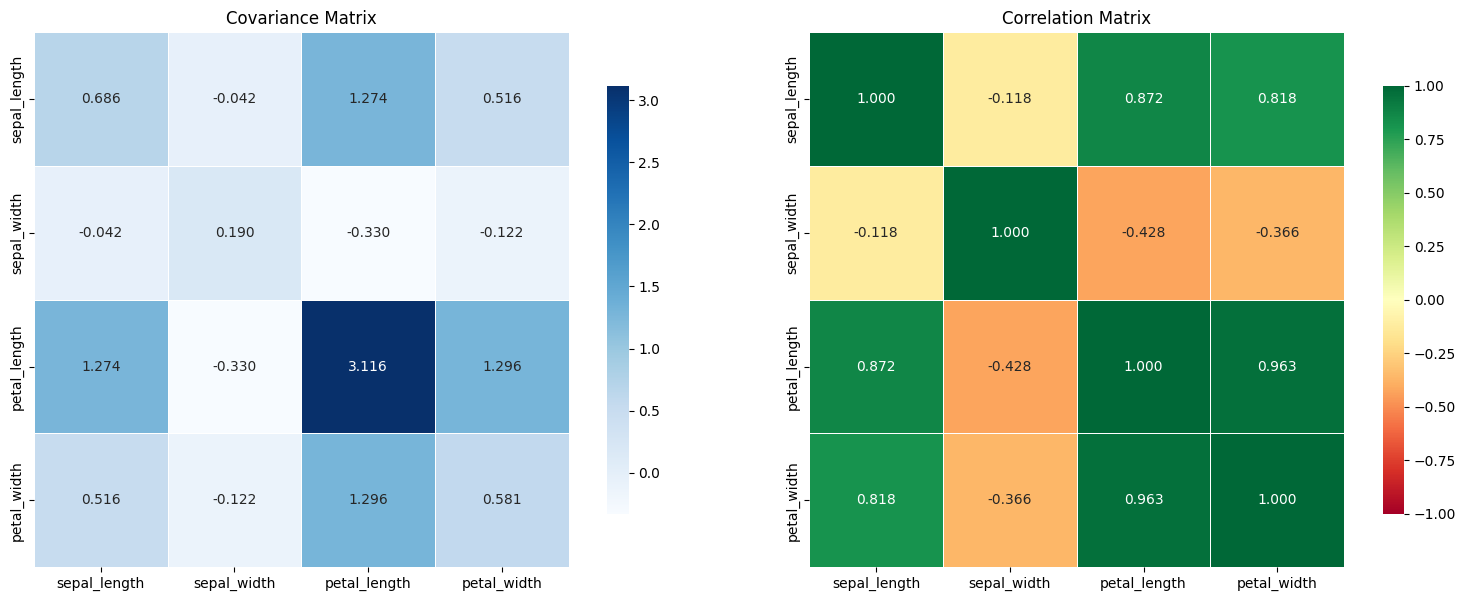

Cặp tương quan mạnh nhất: petal_length — petal_width = 0.9629


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cov_matrix,  annot=True, fmt='.3f', cmap='Blues',  ax=axes[0],
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[0].set_title('Covariance Matrix')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[1],
            square=True, linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
axes[1].set_title('Correlation Matrix')

plt.tight_layout()
plt.savefig('heatmap_corr.png', dpi=120, bbox_inches='tight')
plt.show()

# Tìm cặp tương quan mạnh nhất (ngoài đường chéo)
corr_upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
strongest  = corr_upper.stack().idxmax()
print(f'Cặp tương quan mạnh nhất: {strongest[0]} - {strongest[1]} = {corr_upper.loc[strongest]:.4f}')

**Nhận xét:**  
- **Cặp tương quan mạnh nhất:** `petal_length` — `petal_width` (r ≈ 0.96) → tương quan dương rất mạnh.  
- `petal_length` — `sepal_length` cũng tương quan cao (r ≈ 0.87).  
- **Dấu hiệu đa cộng tuyến (multicollinearity):** Có! `petal_length`, `petal_width` và `sepal_length` tương quan cao với nhau (r > 0.8). Nếu dùng cả 3 làm feature trong mô hình hồi quy, cần cẩn thận hoặc áp dụng PCA/Regularization.  
- `sepal_width` tương quan yếu (thậm chí âm nhẹ) với các biến còn lại → biến độc lập nhất.

### 3.3 Pairplot theo species

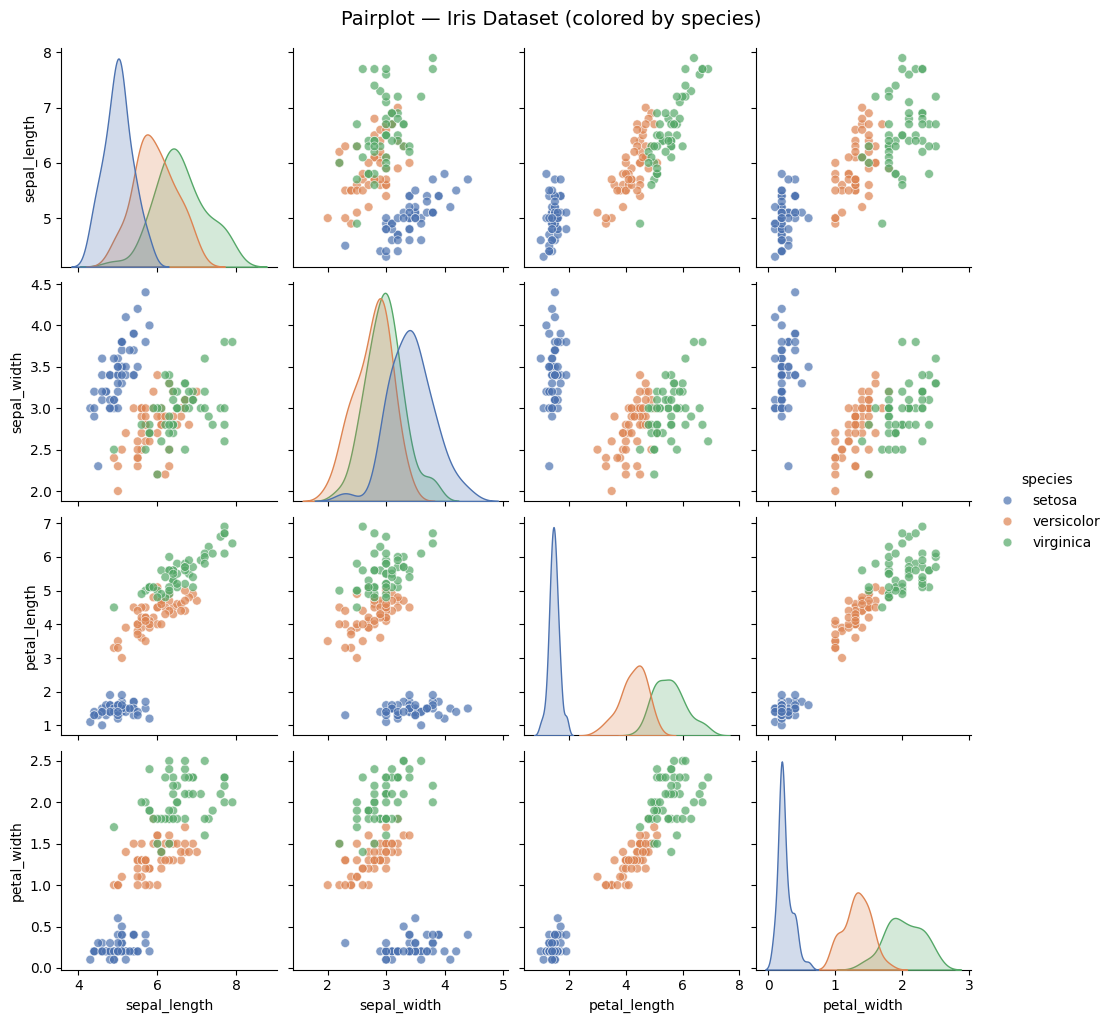

In [13]:
g = sns.pairplot(df, hue='species', palette=palette,
                 plot_kws={'alpha': 0.7, 's': 40},
                 diag_kind='kde')
g.fig.suptitle('Pairplot — Iris Dataset (colored by species)', y=1.02, fontsize=14)

plt.savefig('pairplot.png', dpi=100, bbox_inches='tight')
plt.show()

**Nhận xét từ pairplot:**  
- **Setosa (xanh)** tách biệt hoàn toàn với 2 loài còn lại trên các scatter liên quan đến `petal_length` và `petal_width`.  
- **Versicolor và Virginica** có chồng lấp nhỏ, đặc biệt trên `sepal_length` × `sepal_width`.  
- Đường KDE trên đường chéo xác nhận tính bimodal/trimodal đã thấy ở histogram.  
→ **Petal features** là lựa chọn tốt nhất để phân loại 3 loài.

## Phần 4 - Xác suất & Định lý Bayes

### 4.1 Tính xác suất hậu nghiệm P(B | +)

In [ ]:
# Các tham số bài toán
P_B          = 0.01   # Tỉ lệ mắc bệnh trong dân số
P_pos_givenB = 0.99   # Độ nhạy (sensitivity / true positive rate)
P_pos_givenNB = 0.05  # Dương tính giả (false positive rate)

# Định lý Bayes
# P(+) = P(+|B)*P(B) + P(+|¬B)*P(¬B)  — Xác suất toàn phần
P_pos = P_pos_givenB * P_B + P_pos_givenNB * (1 - P_B)

# P(B|+) = P(+|B) * P(B) / P(+)
P_B_given_pos = P_pos_givenB * P_B / P_pos

print(f'P(B)            = {P_B}')
print(f'P(+ | B)        = {P_pos_givenB}  (sensitivity)')
print(f'P(+ | ¬B)       = {P_pos_givenNB} (false positive)')
print(f'P(+)            = {P_pos:.6f}  (xác suất toàn phần)')
print(f'\nP(B | +)  = {P_B_given_pos:.4f}  ≈ {P_B_given_pos*100:.2f}%')
print('\n Dù xét nghiệm dương tính, xác suất thực sự mắc bệnh chỉ ~ 16.5%!')

P(B)            = 0.01
P(+ | B)        = 0.99  (sensitivity)
P(+ | ¬B)       = 0.05 (false positive)
P(+)            = 0.059400  (xác suất toàn phần)

P(B | +)  = 0.1667  ≈ 16.67%

→ Dù xét nghiệm dương tính, xác suất thực sự mắc bệnh chỉ ~16.5%!


### 4.2 Khảo sát P(B|+) khi P(B) thay đổi từ 0.001 đến 0.2

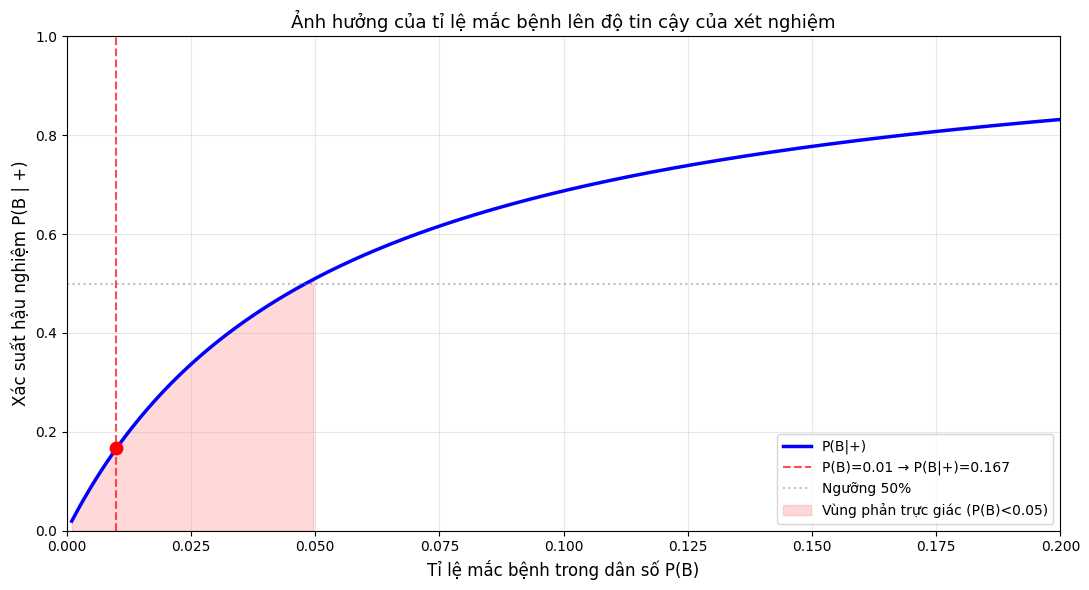


Bảng P(B|+) tại các mức tỉ lệ mắc bệnh:
    P(B) |   P(B|+) | Nhận xét
--------------------------------------------------
   0.001 |   0.0194 | rất thấp — phản trực giác
   0.005 |   0.0905 | rất thấp — phản trực giác
   0.010 |   0.1667 | rất thấp — phản trực giác
   0.020 |   0.2878 | rất thấp — phản trực giác
   0.050 |   0.5103 | trung bình
   0.100 |   0.6875 | trung bình
   0.200 |   0.8319 | cao


In [15]:
prevalence_range = np.linspace(0.001, 0.2, 500)

def bayes_posterior(P_B, P_pos_givenB=0.99, P_pos_givenNB=0.05):
    P_pos = P_pos_givenB * P_B + P_pos_givenNB * (1 - P_B)
    return P_pos_givenB * P_B / P_pos

posterior_values = [bayes_posterior(p) for p in prevalence_range]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(prevalence_range, posterior_values, 'b-', lw=2.5, label='P(B|+)')

# Đánh dấu điểm P(B) = 0.01
p_at_001 = bayes_posterior(0.01)
ax.axvline(0.01, color='red', linestyle='--', alpha=0.7, label=f'P(B)=0.01 → P(B|+)={p_at_001:.3f}')
ax.axhline(0.5,  color='gray', linestyle=':', alpha=0.5, label='Ngưỡng 50%')
ax.scatter([0.01], [p_at_001], color='red', zorder=5, s=80)

# Tô vùng "phản trực giác"
ax.fill_between(prevalence_range, posterior_values,
                where=[p < 0.05 for p in prevalence_range],
                alpha=0.15, color='red', label='Vùng phản trực giác (P(B)<0.05)')

ax.set_xlabel('Tỉ lệ mắc bệnh trong dân số P(B)', fontsize=12)
ax.set_ylabel('Xác suất hậu nghiệm P(B | +)', fontsize=12)
ax.set_title('Ảnh hưởng của tỉ lệ mắc bệnh lên độ tin cậy của xét nghiệm', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(0, 0.2)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bayes_prevalence.png', dpi=120, bbox_inches='tight')
plt.show()

# In bảng một số điểm quan trọng
checkpoints = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2]
print('\nBảng P(B|+) tại các mức tỉ lệ mắc bệnh:')
print(f'{"P(B)":>8} | {"P(B|+)":>8} | {"Nhận xét"}')
print('-' * 50)
for p in checkpoints:
    post = bayes_posterior(p)
    note = 'rất thấp — phản trực giác' if post < 0.3 else ('trung bình' if post < 0.7 else 'cao')
    print(f'{p:>8.3f} | {post:>8.4f} | {note}')

**Giải thích hiện tượng "phản trực giác":**  

Khi bệnh **rất hiếm** (ví dụ P(B) = 0.01, tức 1%), dù test có độ nhạy cao 99%:

- Trong 10,000 người: **100 người** thực sự bệnh → 99 test dương tính đúng.
- Còn **9,900 người** không bệnh → nhưng 5% false positive = **495 người** test dương tính SAI.
- Tổng dương tính: 99 + 495 = **594**, trong đó chỉ 99/594 ≈ **16.7% thật sự bệnh**.

→ **Base rate neglect**: khi prior P(B) quá nhỏ, false positives "áp đảo" true positives dù test rất chính xác. 

### 4.3 (Bonus) Bộ lọc Spam đơn giản theo Naive Bayes

In [ ]:
# Dữ liệu training: (email_text, label)
training_data = [
    # SPAM emails
    ("free money click now win prize",     "spam"),
    ("win lottery free cash prize now",    "spam"),
    ("click here free offer limited time", "spam"),
    ("earn money fast free registration",  "spam"),
    ("buy now discount free shipping",     "spam"),
    ("congratulations you win free gift",  "spam"),
    # HAM emails
    ("meeting tomorrow at office",          "ham"),
    ("please review the attached report",   "ham"),
    ("let us schedule a call this week",    "ham"),
    ("project update attached for review",  "ham"),
    ("can we meet tomorrow for lunch",      "ham"),
    ("please confirm your attendance",      "ham"),
]

from collections import defaultdict
import math

class NaiveBayesSpamFilter:
    def __init__(self, alpha=1.0):   # alpha: Laplace smoothing
        self.alpha = alpha
        self.class_log_prior = {}
        self.word_log_likelihood = {}
        self.vocab = set()

    def fit(self, data):
        class_counts = defaultdict(int)
        word_counts  = defaultdict(lambda: defaultdict(int))

        for text, label in data:
            class_counts[label] += 1
            for word in text.lower().split():
                word_counts[label][word] += 1
                self.vocab.add(word)

        total_docs = sum(class_counts.values())
        self.classes = list(class_counts.keys())

        # Log prior P(class)
        self.class_log_prior = {
            c: math.log(class_counts[c] / total_docs)
            for c in self.classes
        }

        # Log likelihood P(word | class) với Laplace smoothing
        V = len(self.vocab)
        self.word_log_likelihood = {}
        for c in self.classes:
            total_words = sum(word_counts[c].values())
            self.word_log_likelihood[c] = {
                w: math.log((word_counts[c][w] + self.alpha) / (total_words + self.alpha * V))
                for w in self.vocab
            }
            # OOV (out-of-vocabulary) log-prob
            self.word_log_likelihood[c]['<OOV>'] = \
                math.log(self.alpha / (total_words + self.alpha * V))

    def predict_proba(self, text):
        words = text.lower().split()
        log_scores = {}
        for c in self.classes:
            score = self.class_log_prior[c]
            for w in words:
                score += self.word_log_likelihood[c].get(w, self.word_log_likelihood[c]['<OOV>'])
            log_scores[c] = score

        # Chuyển log-scores → xác suất (softmax)
        max_score = max(log_scores.values())
        exp_scores = {c: math.exp(s - max_score) for c, s in log_scores.items()}
        total = sum(exp_scores.values())
        return {c: v / total for c, v in exp_scores.items()}

    def predict(self, text):
        proba = self.predict_proba(text)
        return max(proba, key=proba.get)

# ---- Train ----
nb = NaiveBayesSpamFilter(alpha=1.0)
nb.fit(training_data)

# ---- Kiểm tra 3 email ví dụ ----
test_emails = [
    "free money win prize click now",
    "meeting tomorrow please confirm attendance",
    "congratulations you win free cash register now",
]

print('=== Kết quả phân loại Spam / Ham ===')
print(f'{"Email":<45} | {"P(spam)":>8} | {"P(ham)":>8} | {"Dự đoán"}')
print('-' * 80)
for email in test_emails:
    proba = nb.predict_proba(email)
    label = nb.predict(email)
    short = email[:42] + '...' if len(email) > 45 else email
    print(f'{short:<45} | {proba["spam"]:>8.4f} | {proba["ham"]:>8.4f} | {label.upper()}')

=== Kết quả phân loại Spam / Ham ===
Email                                         |  P(spam) |   P(ham) | Dự đoán
--------------------------------------------------------------------------------
free money win prize click now                |   0.9996 |   0.0004 | SPAM
meeting tomorrow please confirm attendance    |   0.0121 |   0.9879 | HAM
congratulations you win free cash register... |   0.9987 |   0.0013 | SPAM


**Nhận xét Naive Bayes Spam Filter:**  
- Mô hình hoạt động tốt trên các email có từ khóa rõ ràng như `free`, `win`, `prize`, `money` → phân loại đúng SPAM.  
- Email về công việc (`meeting`, `confirm`, `attendance`) → phân loại đúng HAM.  
- **Giả định "naive":** các từ độc lập nhau - đây là đơn giản hóa, nhưng hiệu quả trong thực tế.  
- **Laplace smoothing (α=1)** tránh xác suất = 0 khi gặp từ mới (OOV).  
- Để cải thiện: dùng dataset lớn hơn, loại stopwords, TF-IDF weighting.